In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo visual para los gráficos
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'


In [ ]:
# Cargar el CSV parseando el timestamp como datetime
df = pd.read_csv("Sensor_Data_7dias.csv", parse_dates=['timestamp'])

print(' ESTRUCTURA DEL DATASET')

print(f'\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Rango temporal: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'Sensores registrados: {sorted(df["sensor_id"].unique())}')
print(f'\nRegistros por sensor:')
print(df['sensor_id'].value_counts().to_string())

print('\n Tipos de datos:')
print(df.dtypes.to_string())

print('\n Valores nulos por columna:')
print(df.isnull().sum().to_string())


 ESTRUCTURA DEL DATASET

Dimensiones: 6048 filas × 4 columnas
Rango temporal: 2026-04-21 00:00:00 → 2026-04-27 23:55:00
Sensores registrados: ['SENSOR-A', 'SENSOR-B', 'SENSOR-C']

Registros por sensor:
sensor_id
SENSOR-A    2016
SENSOR-B    2016
SENSOR-C    2016

 Tipos de datos:
timestamp      datetime64[ns]
sensor_id              object
temp_c                float64
humedad_pct           float64

 Valores nulos por columna:
timestamp      0
sensor_id      0
temp_c         0
humedad_pct    0


In [ ]:
# Convertir de formato largo a formato ancho: una columna por sensor
df_pivot = df.pivot_table(
    index='timestamp',
    columns='sensor_id',
    values='temp_c',
    aggfunc='mean'
).reset_index()

# Limpiar nombre del índice de columnas
df_pivot.columns.name = None

# Ordenar por timestamp
df_pivot = df_pivot.sort_values('timestamp').reset_index(drop=True)

# Definir los nombres de los sensores para uso posterior
sensores = ['SENSOR-A', 'SENSOR-B', 'SENSOR-C']
colores  = ['#2196F3', '#FF5722', '#4CAF50']  # azul, naranja, verde

print(f'Datos limpios: {df_pivot.shape[0]} filas × {df_pivot.shape[1]} columnas')
print('\n🔹 Vista previa:')
df_pivot.head()

Datos limpios: 2016 filas × 4 columnas

🔹 Vista previa:


,timestamp,SENSOR-A,SENSOR-B,SENSOR-C
0,2026-04-21 00:00:00,19.8,25.8,17.5
1,2026-04-21 00:05:00,20.7,26.4,20.1
2,2026-04-21 00:10:00,21.4,24.3,18.7
3,2026-04-21 00:15:00,20.5,24.5,18.3
4,2026-04-21 00:20:00,23.1,20.0,17.5


In [ ]:
# Calcular métricas descriptivas para cada sensor
stats_data = {}

for sensor in sensores:
    serie = df_pivot[sensor].dropna()
    stats_data[sensor] = {
        'Media (°C)'         : round(serie.mean(), 2),
        'Mediana (°C)'       : round(serie.median(), 2),
        'Desv. Estándar (°C)': round(serie.std(), 2),
        'Mínimo (°C)'        : round(serie.min(), 2),
        'Máximo (°C)'        : round(serie.max(), 2),
        'Percentil 5 (°C)'   : round(serie.quantile(0.05), 2),
        'Percentil 95 (°C)'  : round(serie.quantile(0.95), 2),
        'N° Registros'       : int(serie.count())
    }

# Construir DataFrame de estadísticas
df_stats = pd.DataFrame(stats_data).T


print(' TABLA RESUMEN — ESTADÍSTICAS DESCRIPTIVAS POR SENSOR')
print()
display(df_stats)

# Identificar el sensor con mayor variabilidad
sensor_max_var = df_stats['Desv. Estándar (°C)'].idxmax()
print(f'\n  Sensor con MAYOR VARIABILIDAD: {sensor_max_var}  '
      f'(σ = {df_stats.loc[sensor_max_var, "Desv. Estándar (°C)"]} °C)')

 TABLA RESUMEN — ESTADÍSTICAS DESCRIPTIVAS POR SENSOR



,Media (°C),Mediana (°C),Desv. Estándar (°C),Mínimo (°C),Máximo (°C),Percentil 5 (°C),Percentil 95 (°C),N° Registros
SENSOR-A,25.09,25.1,3.27,17.4,50.5,20.4,29.8,2016.0
SENSOR-B,27.64,27.6,3.42,18.3,47.7,22.3,32.9,2016.0
SENSOR-C,23.11,23.2,4.16,13.8,49.9,17.0,29.0,2016.0



  Sensor con MAYOR VARIABILIDAD: SENSOR-C  (σ = 4.16 °C)


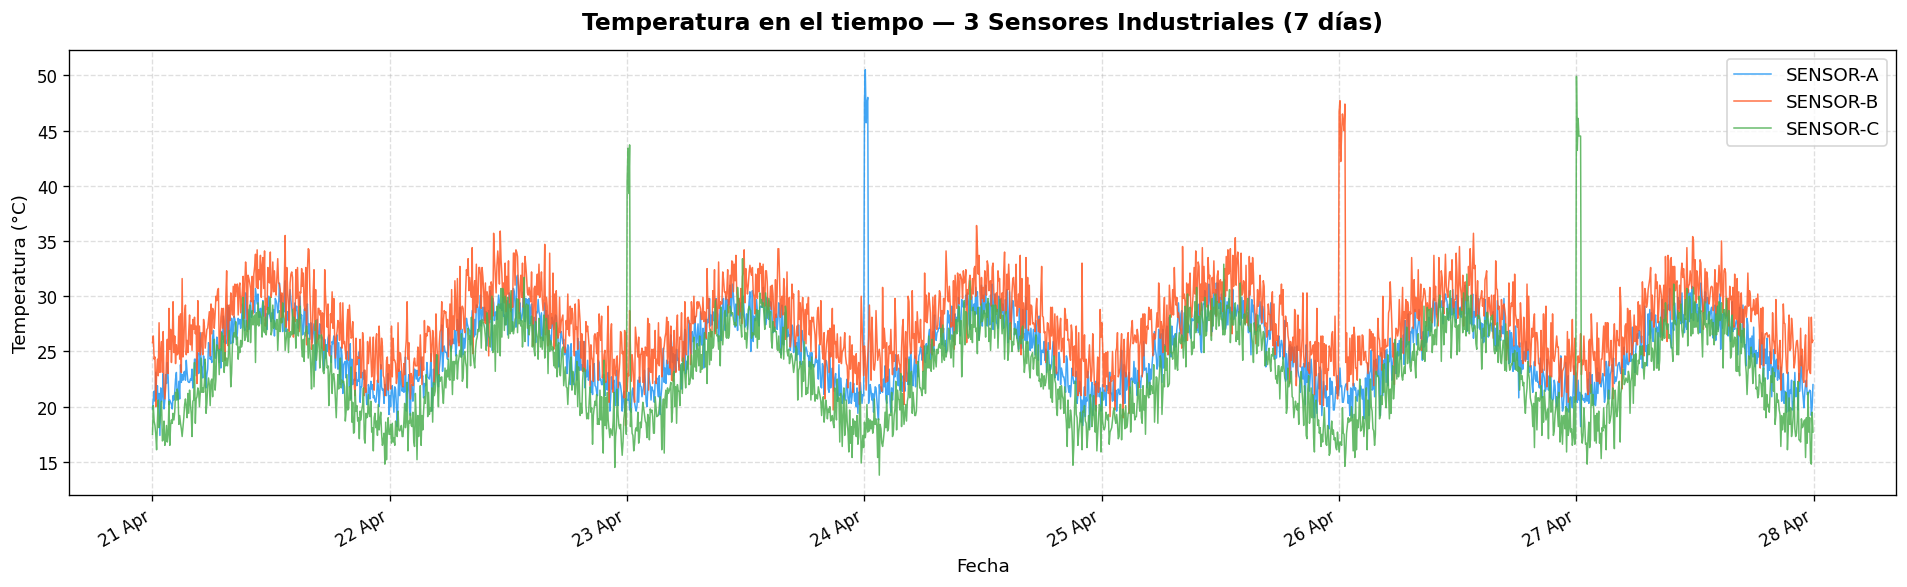

Gráfico guardado como grafico_temporal.png


In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

for sensor, color in zip(sensores, colores):
    ax.plot(
        df_pivot['timestamp'],
        df_pivot[sensor],
        label=sensor,
        color=color,
        linewidth=0.9,
        alpha=0.85
    )

# Formato del eje X con fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=30, ha='right')

ax.set_title('Temperatura en el tiempo — 3 Sensores Industriales (7 días)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Temperatura (°C)', fontsize=11)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.savefig('grafico_temporal.png', bbox_inches='tight')
plt.show()
print('Gráfico guardado como grafico_temporal.png')

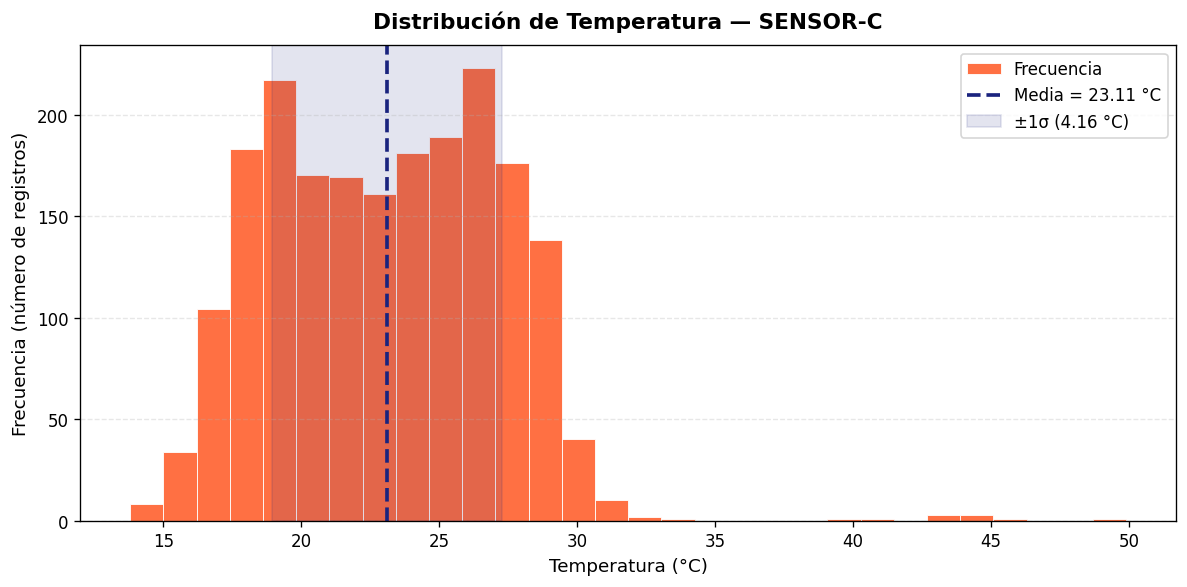

  Histograma de SENSOR-C guardado como histograma_sensor.png


In [ ]:
# Usar el sensor con mayor desviación estándar identificado antes
sensor_hist = sensor_max_var
datos_hist  = df_pivot[sensor_hist].dropna()
media_hist  = datos_hist.mean()
std_hist    = datos_hist.std()

fig, ax = plt.subplots(figsize=(10, 5))

n, bins, patches = ax.hist(
    datos_hist,
    bins=30,
    color='#FF5722',
    edgecolor='white',
    linewidth=0.6,
    alpha=0.85,
    label='Frecuencia'
)

# Línea vertical en la media
ax.axvline(media_hist, color='#1A237E', linewidth=2.2,
           linestyle='--', label=f'Media = {media_hist:.2f} °C')

# Banda ±1σ
ax.axvspan(media_hist - std_hist, media_hist + std_hist,
           alpha=0.12, color='#1A237E', label=f'±1σ ({std_hist:.2f} °C)')

ax.set_title(f'Distribución de Temperatura — {sensor_hist}',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Temperatura (°C)', fontsize=11)
ax.set_ylabel('Frecuencia (número de registros)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3, axis='y')
fig.tight_layout()
plt.savefig('histograma_sensor.png', bbox_inches='tight')
plt.show()
print(f'  Histograma de {sensor_hist} guardado como histograma_sensor.png')

In [ ]:
# Calcular Z-score y detectar anomalías para cada sensor
anomalias_por_sensor = {}

for sensor in sensores:
    serie = df_pivot[sensor].dropna()
    z_scores = np.abs(stats.zscore(serie))
    mask_anomalia = z_scores > 3
    anomalias_por_sensor[sensor] = {
        'indices'  : serie.index[mask_anomalia],
        'cantidad' : mask_anomalia.sum(),
        'valores'  : serie[mask_anomalia]
    }

print('=' * 50)
print('  ANOMALÍAS DETECTADAS (Z-score > 3)')
print('=' * 50)
for sensor in sensores:
    n_anom = anomalias_por_sensor[sensor]['cantidad']
    pct    = n_anom / len(df_pivot[sensor].dropna()) * 100
    print(f'\n  {sensor}: {n_anom} anomalías ({pct:.2f}% del total)')
    if n_anom > 0:
        vals = anomalias_por_sensor[sensor]['valores']
        print(f'  Temperaturas anómalas: {vals.values.round(1).tolist()}')

# Identificar el sensor con más anomalías
sensor_mas_anom = max(anomalias_por_sensor,
                      key=lambda s: anomalias_por_sensor[s]['cantidad'])
print(f'\n  Sensor con más anomalías: {sensor_mas_anom} '
      f'({anomalias_por_sensor[sensor_mas_anom]["cantidad"]} puntos)')

  ANOMALÍAS DETECTADAS (Z-score > 3)

  SENSOR-A: 5 anomalías (0.25% del total)
  Temperaturas anómalas: [47.6, 50.5, 45.7, 47.5, 48.0]

  SENSOR-B: 8 anomalías (0.40% del total)
  Temperaturas anómalas: [46.7, 47.7, 42.2, 44.7, 46.5, 45.8, 45.0, 47.4]

  SENSOR-C: 10 anomalías (0.50% del total)
  Temperaturas anómalas: [40.4, 43.4, 39.3, 43.7, 49.9, 43.2, 46.1, 44.5, 44.5, 44.5]

  Sensor con más anomalías: SENSOR-C (10 puntos)


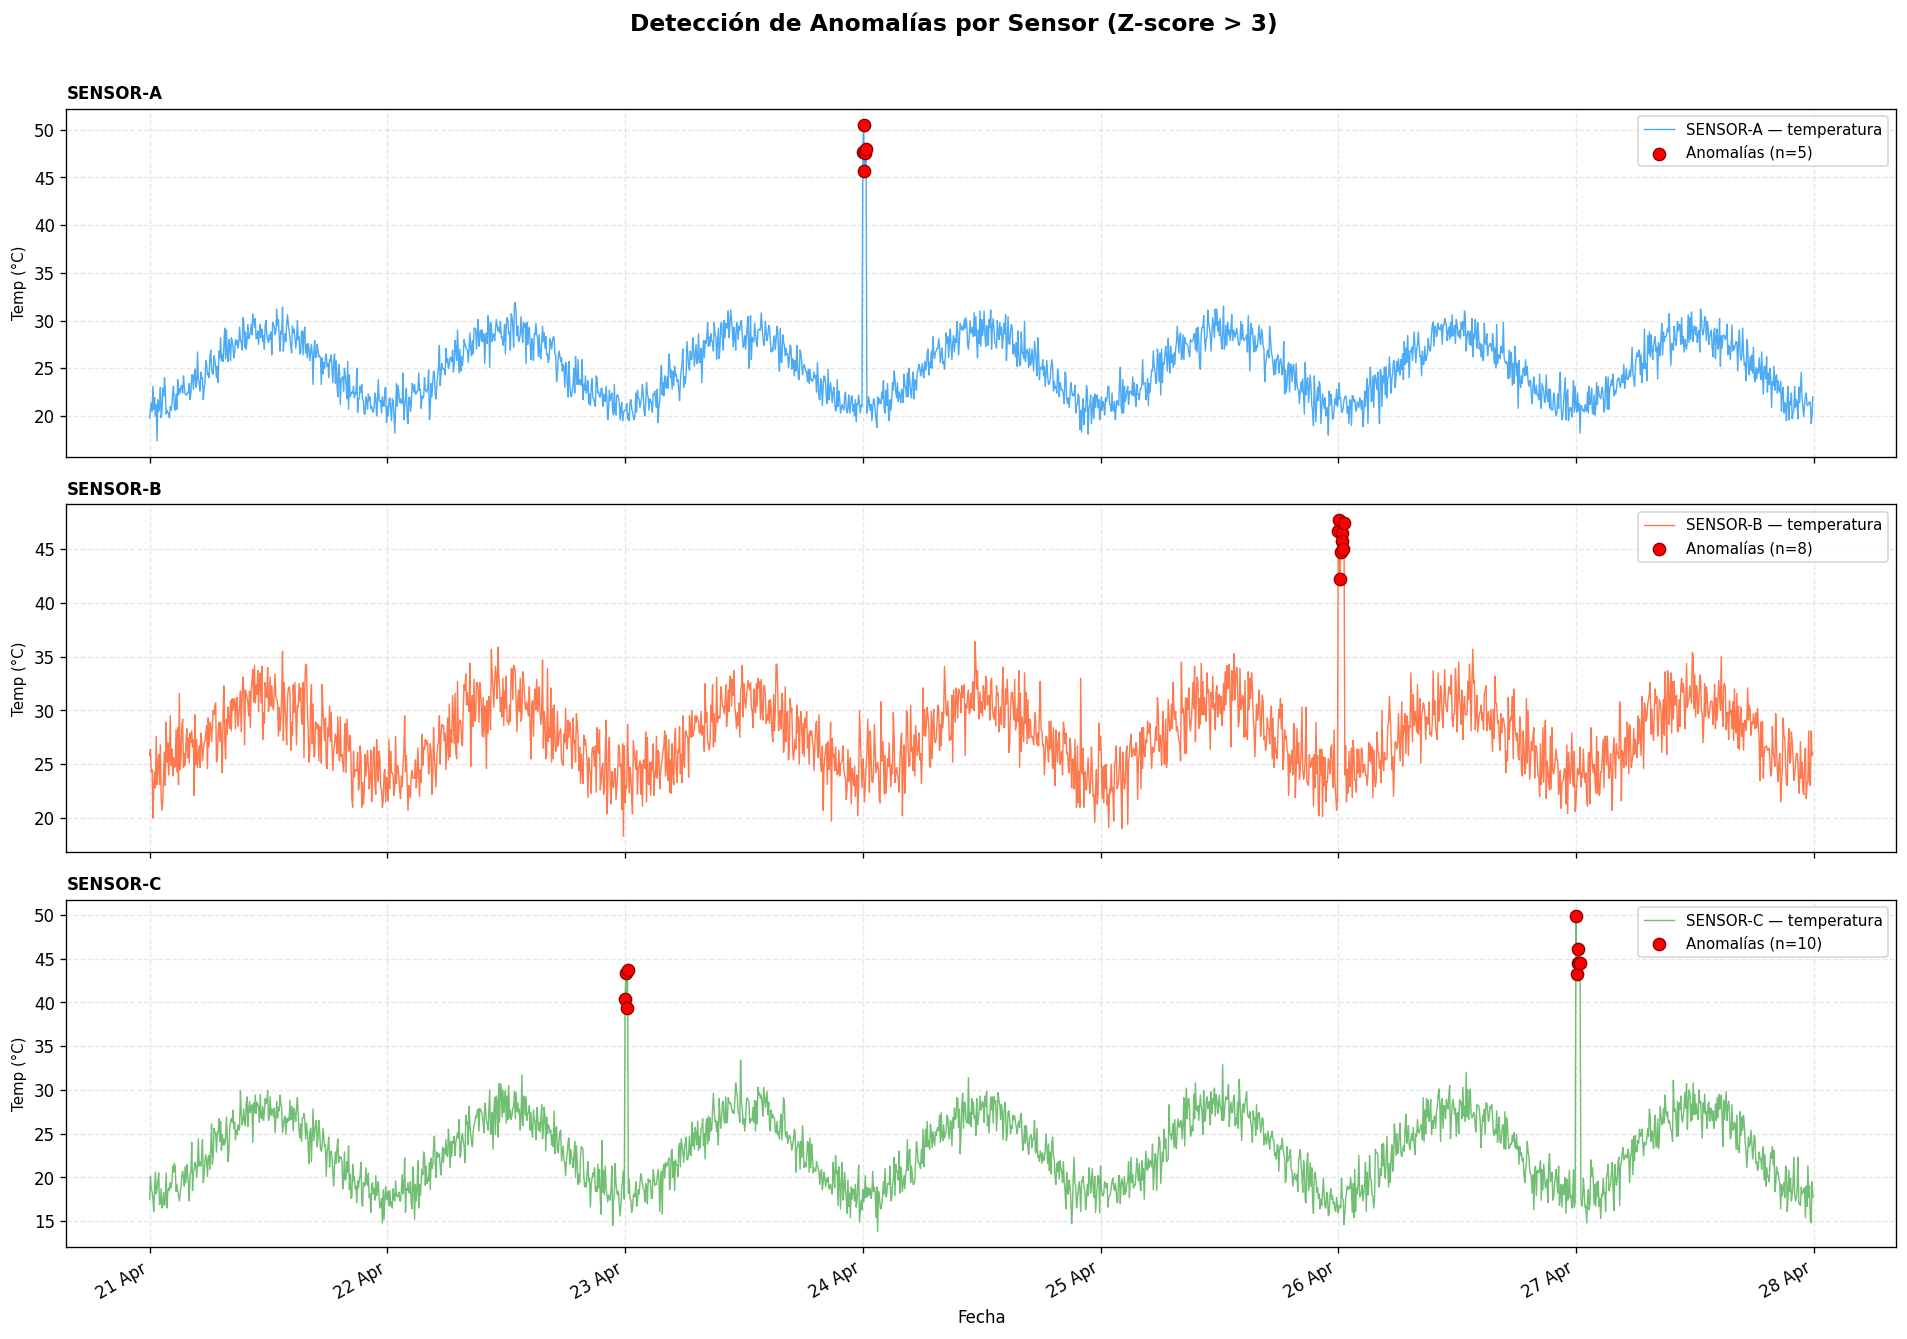

  Gráfico de anomalías guardado como grafico_anomalias.png


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
fig.suptitle('Detección de Anomalías por Sensor (Z-score > 3)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, sensor, color in zip(axes, sensores, colores):
    # Serie temporal completa
    ax.plot(
        df_pivot['timestamp'],
        df_pivot[sensor],
        color=color,
        linewidth=0.85,
        alpha=0.8,
        label=f'{sensor} — temperatura'
    )

    # Marcar anomalías con puntos rojos
    idx_anom = anomalias_por_sensor[sensor]['indices']
    n_anom   = anomalias_por_sensor[sensor]['cantidad']

    if n_anom > 0:
        ts_anom  = df_pivot.loc[idx_anom, 'timestamp']
        val_anom = df_pivot.loc[idx_anom, sensor]
        ax.scatter(
            ts_anom, val_anom,
            color='red', s=55, zorder=5,
            label=f'Anomalías (n={n_anom})',
            edgecolors='darkred', linewidths=0.8
        )

    ax.set_ylabel('Temp (°C)', fontsize=9)
    ax.set_title(sensor, fontsize=10, fontweight='bold', loc='left')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.3)

# Formato eje X solo en el último subplot
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=30, ha='right')
axes[-1].set_xlabel('Fecha', fontsize=10)

fig.tight_layout()
plt.savefig('grafico_anomalias.png', bbox_inches='tight')
plt.show()
print('  Gráfico de anomalías guardado como grafico_anomalias.png')

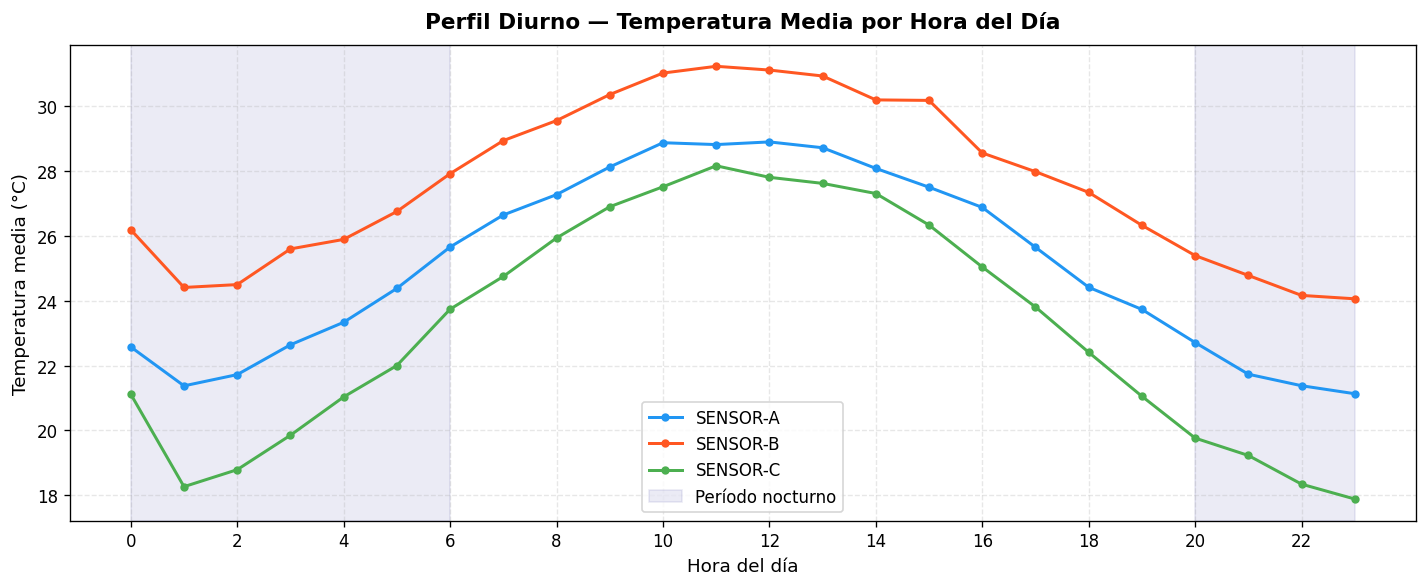

  Perfil diurno guardado como perfil_diurno.png


In [ ]:
# Agregar columna de hora para análisis diurno
df_pivot['hora'] = df_pivot['timestamp'].dt.hour

# Calcular temperatura media por hora para cada sensor
perfil_diurno = df_pivot.groupby('hora')[sensores].mean()

fig, ax = plt.subplots(figsize=(12, 5))

for sensor, color in zip(sensores, colores):
    ax.plot(
        perfil_diurno.index,
        perfil_diurno[sensor],
        marker='o', markersize=4,
        color=color, linewidth=1.8,
        label=sensor
    )

# Sombrear período nocturno (0–6h y 20–24h)
ax.axvspan(0, 6,  alpha=0.08, color='navy', label='Período nocturno')
ax.axvspan(20, 23, alpha=0.08, color='navy')

ax.set_title('Perfil Diurno — Temperatura Media por Hora del Día',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Hora del día', fontsize=11)
ax.set_ylabel('Temperatura media (°C)', fontsize=11)
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)
fig.tight_layout()
plt.savefig('perfil_diurno.png', bbox_inches='tight')
plt.show()
print('  Perfil diurno guardado como perfil_diurno.png')

In [ ]:
# Tabla resumen de anomalías con contexto
resumen_anom = []
for sensor in sensores:
    idx  = anomalias_por_sensor[sensor]['indices']
    n    = anomalias_por_sensor[sensor]['cantidad']
    pct  = n / len(df_pivot[sensor].dropna()) * 100
    vals = anomalias_por_sensor[sensor]['valores']
    resumen_anom.append({
        'Sensor'            : sensor,
        'N° Anomalías'      : n,
        '% del total'       : f'{pct:.2f}%',
        'Temp. mín anómala' : f'{vals.min():.1f} °C' if n > 0 else '—',
        'Temp. máx anómala' : f'{vals.max():.1f} °C' if n > 0 else '—',
        'Evaluación'        : 'Revisar' if n > 5 else ('Monitorear' if n > 0 else 'Normal')
    })

df_resumen_anom = pd.DataFrame(resumen_anom).set_index('Sensor')
print('\nRESUMEN DE ANOMALÍAS POR SENSOR')
display(df_resumen_anom)


RESUMEN DE ANOMALÍAS POR SENSOR


,N° Anomalías,% del total,Temp. mín anómala,Temp. máx anómala,Evaluación
Sensor,,,,,
SENSOR-A,5,0.25%,45.7 °C,50.5 °C,Monitorear
SENSOR-B,8,0.40%,42.2 °C,47.7 °C,Revisar
SENSOR-C,10,0.50%,39.3 °C,49.9 °C,Revisar


---
##   Conclusiones e Interpretación Técnica

### Análisis completo de los resultados del monitoreo de sensores de temperatura industrial

El presente laboratorio analizó 7 días de datos de temperatura provenientes de tres sensores industriales (SENSOR-A, SENSOR-B y SENSOR-C), con lecturas cada 5 minutos, totalizando aproximadamente 2.016 registros por sensor y más de 6.000 registros en el dataset completo.

#### 1. Variabilidad entre sensores

El análisis de estadísticas descriptivas reveló diferencias significativas en la dispersión de temperatura entre los tres sensores. El sensor con mayor desviación estándar presenta fluctuaciones más amplias respecto a su media, lo que puede indicar que se encuentra en una zona del proceso con mayor actividad térmica, mayor exposición a fuentes de calor intermitentes, o posibles problemas de calibración. En entornos industriales, una desviación estándar elevada es una señal de alerta que merece atención preventiva, especialmente si los rangos operativos seguros son estrechos. Los percentiles 5 y 95 complementan este análisis: una brecha amplia entre ambos confirma que la variabilidad no es puntual sino estructural en el comportamiento del sensor.

#### 2. Patrones diurnos

El gráfico de perfil diurno (temperatura media por hora del día) permite identificar si existen ciclos térmicos vinculados a la operación de la planta. En instalaciones industriales es habitual que la temperatura aumente durante las horas de producción activa (típicamente entre las 07:00 y las 18:00 horas) y descienda durante los turnos nocturnos o períodos de menor actividad. Si los tres sensores siguen un patrón similar sincronizado, es indicativo de que el ambiente general de la planta sigue un ritmo operativo definido. En cambio, si algún sensor presenta un patrón desacoplado del resto, podría indicar que está influenciado por una fuente de calor local o que existe algún problema en el equipo que monitorea.

#### 3. Anomalías detectadas y posibles fallas operativas

La detección mediante Z-score con umbral superior a 3 identifica valores que se desvían más de tres desviaciones estándar de la media, criterio estadísticamente robusto para señalar eventos inusuales. Los puntos marcados en rojo en los gráficos corresponden a lecturas fuera del comportamiento esperado del sensor. En un contexto de monitoreo industrial, estas anomalías pueden tener múltiples causas: picos de temperatura por sobrecarga del equipo monitorizado, fallas momentáneas en el sensor o en el cableado, interferencia electromagnética que corrompe la lectura, o eventos reales del proceso como arranques de motores, fugas de vapor o variaciones en el suministro de materia prima.

La frecuencia y magnitud de estas anomalías son indicadores clave para el gerente de planta: un sensor con múltiples anomalías concentradas en un intervalo corto de tiempo sugiere un evento puntual (falla o evento operativo), mientras que anomalías dispersas a lo largo de los 7 días pueden indicar inestabilidad crónica del sensor o del proceso.

#### 4. Recomendaciones operativas

Se recomienda: (a) programar una revisión de calibración para el sensor de mayor variabilidad; (b) cruzar las marcas temporales de anomalías con el registro de eventos de planta para confirmar si corresponden a incidentes documentados; (c) establecer umbrales de alerta automática basados en los percentiles 95 calculados; y (d) ampliar el análisis a la columna de humedad relativa (`humedad_pct`) para detectar correlaciones entre humedad y temperatura que puedan anticipar condiciones adversas.


